## Cell 1 ｜ 环境与依赖

In [1]:
# Cell 1: 环境与依赖
%load_ext autoreload
%autoreload 2

import os
import sys
import json
import time
import random
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from openai import OpenAI
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# 让 Python 能找到 src/ 下的 Piao 模块（utils.py / simulate.py）
# notebook 在 pilot-2.0/ 内、与 src/ 同级，CWD 就是 pilot-2.0/，所以 "src" 就能找到
sys.path.append("src")

# 从系统环境变量读 API key（你已配置好，不走 .env）
API_KEY = os.environ.get("DASHSCOPE_API_KEY", "")
assert API_KEY, "❌ 没读到 DASHSCOPE_API_KEY，请重启 VS Code / Jupyter（环境变量在已打开的进程里不会刷新）"

# 初始化 DashScope OpenAI 兼容 client
client = OpenAI(
    api_key=API_KEY,
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
)

# 选模型：对齐 v2.1 设计文档选型（Qwen3-8B instruct，中文议题线主力）
MODEL_NAME = "qwen3-8b"
print(f"✅ Client ready, model = {MODEL_NAME}")

# === LLM 调用带重试包装（2026-05-24 新增） ===
# DashScope 偶发 APIConnectionError / 5xx / 429（粗估 1-2% 调用），原本 cell 5 没兜底直接挂，
# cell 6/7 的 except 又是 silent fallback（raw="" + 维持旧 label）会污染分布观察。
# 改成下面这个工具函数：仅对网络/限流/服务端错误指数退避重试，参数错立即抛。
from openai import APIConnectionError, APITimeoutError, RateLimitError, InternalServerError

def call_llm(prompt, model=None, temperature=0.7, max_tokens=300, max_retries=3, base_delay=1.0):
    model = model or MODEL_NAME
    for attempt in range(max_retries + 1):
        try:
            resp = client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                extra_body={"enable_thinking": False},
                temperature=temperature,
                max_tokens=max_tokens,
            )
            return resp.choices[0].message.content, resp.usage
        except (APIConnectionError, APITimeoutError, RateLimitError, InternalServerError) as e:
            if attempt < max_retries:
                delay = base_delay * (2 ** attempt)
                print(f"  ⚠️ [retry {attempt+1}/{max_retries}] {type(e).__name__}; sleep {delay}s")
                time.sleep(delay)
            else:
                print(f"  ❌ 重试 {max_retries} 次后仍失败: {type(e).__name__}: {e}")
                raise

c:\Users\Bai Yuexi\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Client ready, model = qwen3-8b


## Cell 2 ｜ 单次调用 sanity check

In [2]:
# Cell 2: 单次调用 sanity check
resp = client.chat.completions.create(
    model=MODEL_NAME,
    messages=[
        {"role": "user", "content": "用一句中文说你好。"}
    ],
    extra_body={"enable_thinking": False},  # ⚠️ Qwen3 必须显式关闭 hybrid thinking
    temperature=0.7,
)
print("Raw response:")
print(resp.choices[0].message.content)
print("\nUsage:", resp.usage)

Raw response:
你好！

Usage: CompletionUsage(completion_tokens=2, prompt_tokens=18, total_tokens=20, completion_tokens_details=None, prompt_tokens_details=None)


## Cell 3 ｜ 生成 Data_WS_80 小网络

用 networkx 生成 N=80, ⟨k⟩=6, p=0.1 的 Watts-Strogatz 网络，导成 Piao 仓库期望的 CSV 格式，存到 pilot-2.0/data/WS_80/ 目录（与 pilot-2.0/data/WS_2000/ 同级）。

生成 WS 网络：N=80, ⟨k⟩=6, p=0.1
实际节点数 80, 边数 240
平均度 6.00
聚类系数 0.462

✅ 三个文件落地到 data\WS_80/


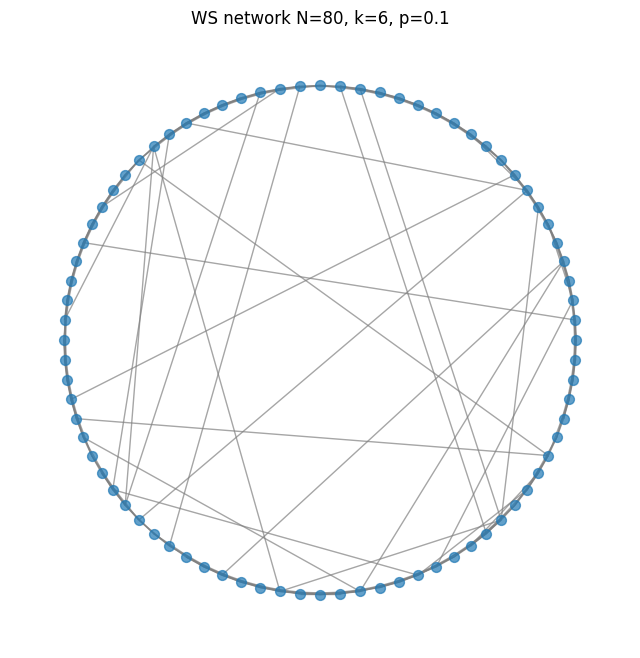

In [3]:
# Cell 3: 生成小网络
N = 80
K = 6      # 平均度
P = 0.1    # 重连概率
SEED = 42  # 固定随机种子，跨条件可复现

random.seed(SEED)
np.random.seed(SEED)

g = nx.watts_strogatz_graph(n=N, k=K, p=P, seed=SEED)
print(f"生成 WS 网络：N={N}, ⟨k⟩={K}, p={P}")
print(f"实际节点数 {g.number_of_nodes()}, 边数 {g.number_of_edges()}")
print(f"平均度 {2 * g.number_of_edges() / g.number_of_nodes():.2f}")
print(f"聚类系数 {nx.average_clustering(g):.3f}")

# 转有向图（Piao 原版用 DiGraph）
dg = g.to_directed()

# 导出 edges.csv（Piao 格式：source, target）
# notebook 在 pilot-2.0/ 内，CWD 就是 pilot-2.0/，所以 "data/WS_80" 落到 pilot-2.0/data/WS_80/
out_dir = Path("data/WS_80")
out_dir.mkdir(parents=True, exist_ok=True)

edges_df = pd.DataFrame(
    [(u, v) for u, v in dg.edges()],
    columns=["source", "target"]
)
edges_df.to_csv(out_dir / "edges.csv", index=False)

# 导出 data_ID2Net_ID.csv（节点 ID 映射，最简单的同 ID）
# Piao 真实列名：单列 Network_id（simulate.py 里 usecols=["Network_id"]）
id_map_df = pd.DataFrame({"Network_id": list(range(N))})
id_map_df.to_csv(out_dir / "data_ID2Net_ID.csv", index=False)

# user_message_generate.json：Piao 原代码要求每个节点都有 key（即使是空 list）
# 教学版 cell 6/7 不读这个文件；§五 用 Piao 原版 simulate_debiased.py 复刻时会读它，缺 key 会 KeyError
with open(out_dir / "user_message_generate.json", "w") as f:
    json.dump({str(i): [] for i in range(N)}, f)

print(f"\n✅ 三个文件落地到 {out_dir}/")

# 可视化一下网络（可选）
fig, ax = plt.subplots(figsize=(8, 8))
nx.draw_circular(g, node_size=50, alpha=0.7, ax=ax, edge_color="gray")
ax.set_title(f"WS network N={N}, k={K}, p={P}")
plt.show()

## Cell 4 ｜ prompt 模板预览

从 Piao 主文件里抽出 5 段式 prompt 模板（environment / topic / S_m2..S_p2 / explanation / side description），渲染成一条具体的 prompt 给你**肉眼审阅**。这一步**不调 LLM，不花钱**。

In [4]:
# Cell 4: prompt 模板预览
# 以下 13 个字符串直接来自 Piao 仓库 run.py（Politics 议题，默认配置，已核验）。
# 想换中文议题（如延迟退休 / AI 取代劳动力 / 三孩生育）只需把下面 13 个串换成中文版，五档结构不变。

environment = "Sociopolitical"
topic = "Politics"

S_m2 = "strongly support the Republican party"
S_m1 = "support the Republican party"
S_0 = "don't have a tendency"
S_p1 = "support the Democratic party"
S_p2 = "Strongly support the Democratic party"

S_m2_e = "the Republic party is absolutely better than the Democratic party in every aspect."
S_m1_e = "the Republican party and the Democratic party both have ups and downs, but the Republican party have a slight edge."
S_0_e = "doesn't lean towards or favor either the Democratic or Republican party."
S_p1_e = "the Democratic party and the Republican party both have ups and downs, but the Democratic party have a slight edge."
S_p2_e = "the Democratic party is absolutely better than the Republican party in every aspect."

side_s_0 = "Support the Republican party"
side_e_0 = "Maintain neutrality"
side_b_0 = "Support the Democratic party"

# 一个示例 agent 的渲染（这里只是给你看 prompt 长啥样，真正调用见 cell 5/6）
example_prompt = f"""You are participating in a discussion about {topic} in {environment}.

There are five possible standpoints:
- {S_m2}: {S_m2_e}
- {S_m1}: {S_m1_e}
- {S_0}: {S_0_e}
- {S_p1}: {S_p1_e}
- {S_p2}: {S_p2_e}

Your current side: {side_e_0}

You observed the following recent comments from your neighbors:
1. [Neighbor A]: "Sample comment 1"
2. [Neighbor B]: "Sample comment 2"

Now express your own view in 1-2 sentences and end with your standpoint label (one of S_m2 / S_m1 / S_0 / S_p1 / S_p2).
"""

print(example_prompt)

You are participating in a discussion about Politics in Sociopolitical.

There are five possible standpoints:
- strongly support the Republican party: the Republic party is absolutely better than the Democratic party in every aspect.
- support the Republican party: the Republican party and the Democratic party both have ups and downs, but the Republican party have a slight edge.
- don't have a tendency: doesn't lean towards or favor either the Democratic or Republican party.
- support the Democratic party: the Democratic party and the Republican party both have ups and downs, but the Democratic party have a slight edge.
- Strongly support the Democratic party: the Democratic party is absolutely better than the Republican party in every aspect.

Your current side: Maintain neutrality

You observed the following recent comments from your neighbors:
1. [Neighbor A]: "Sample comment 1"
2. [Neighbor B]: "Sample comment 2"

Now express your own view in 1-2 sentences and end with your standpo

## Cell 5 ｜ 单 agent 单 step 跑通

用 cell 4 拼出来的 prompt 真正调一次 LLM，看 Qwen3 给出什么响应、能不能稳定按 Piao 期望的格式（含 `S_m2` / `S_m1` / `S_0` / `S_p1` / `S_p2` 任一标签）输出。这是最关键的一步——**前面所有都准备完了，就看 LLM 一步行为对不对**。

In [5]:
# Cell 5: 单 agent 单 step 跑通
# 用 cell 1 定义的 call_llm，自动重试 3 次应对 DashScope 偶发连接抖动
raw, usage = call_llm(example_prompt, temperature=0.7, max_tokens=300)
print("=== Raw response ===")
print(raw)
print("\n=== Usage ===")
print(usage)

# 严匹配版立场解析（2026-05-24 更新）
# 原版 substring 匹配有两个 bug：
#   (1) raw 里引用了 prompt 中 5 档定义文本时，会被误 parse 为首个出现的标签（例如 LLM 实际说「I support Democratic」但 raw 中包含 S_m2 字面值，被 parse 成 S_m2）
#   (2) “S_m” 会与 “S_m1” / “S_m2” 作子串匹配（原版靠顺序避开，但仍是不鲁棒）
import re
_LABEL_RE = re.compile(r"\bS_(?:m2|m1|p2|p1|0)\b")

def parse_standpoint(text):
    """取文本中最后一次出现的标签（LLM 通常在末尾表态，prompt 也明说 'end with your standpoint label'）。
    用 \\b 词边界确保只匹配独立 token，避免 substring 误匹配。"""
    if not text:
        return None
    matches = _LABEL_RE.findall(text)
    return matches[-1] if matches else None

parsed = parse_standpoint(raw)
print(f"\n=== Parsed standpoint: {parsed} ===")
if parsed is None:
    print("⚠️ 解析失败：Qwen3 没按格式输出，需要调 prompt 或 system message")

=== Raw response ===
I appreciate the diversity of opinions, but I believe it's important to focus on shared values and common goals rather than partisan divisions. I don't have a tendency to favor either party.  
S_0

=== Usage ===
CompletionUsage(completion_tokens=41, prompt_tokens=232, total_tokens=273, completion_tokens_details=None, prompt_tokens_details=None)

=== Parsed standpoint: S_0 ===


## Cell 6 ｜ 小规模串行 N=10, t=2

跑一个真正的 mini 仿真——10 个 agent，2 个 epoch，**完全单线程串行**。目的是看清主循环是怎么走的、估算每 agent step 的耗时。

In [6]:
# Cell 6: 小规模串行跑 N=10, t=2
N_MINI = 10
T_MINI = 2
results = []

# 简化的网络：完全图（10 个 agent，所有人都互相是邻居）
# 真实跑时应该用 cell 3 的 WS 网络，先用完全图把主循环跑通
mini_g = nx.complete_graph(N_MINI)

# 初始化每个 agent 的立场（随机 5 档之一）
labels = ["S_m2", "S_m1", "S_0", "S_p1", "S_p2"]
agent_state = {i: {"label": random.choice(labels), "history": []} for i in range(N_MINI)}

print("=== 初始状态 ===")
for i, s in agent_state.items():
    print(f"Agent {i}: {s['label']}")

for t in range(T_MINI):
    print(f"\n=== Epoch {t} ===")
    for agent_id in tqdm(range(N_MINI), desc=f"t={t}"):
        # 1. 取邻居最近发言（这里简化：随机抽 3 个邻居的当前立场）
        neighbors = list(mini_g.neighbors(agent_id))
        sampled = random.sample(neighbors, min(3, len(neighbors)))
        neighbor_comments = [f"[Neighbor {n}]: standpoint={agent_state[n]['label']}" for n in sampled]
        
        # 2. 把当前立场映射到对应的 side 描述（修了 v1 的塌缩 bug：之前所有 agent 看到的 prompt 都写死「Your current side: Maintain neutrality」，被推向 S_0）
        label2side = {
            "S_m2": side_s_0, "S_m1": side_s_0,   # 共和侧
            "S_0":  side_e_0,                       # 中立
            "S_p1": side_b_0, "S_p2": side_b_0,   # 民主侧
        }
        current_side = label2side[agent_state[agent_id]["label"]]
        
        # 拼 prompt（同时替换 current side 和邻居发言）
        prompt = (example_prompt
            .replace(f"Your current side: {side_e_0}", f"Your current side: {current_side}")
            .replace(
                '1. [Neighbor A]: "Sample comment 1"\n2. [Neighbor B]: "Sample comment 2"',
                "\n".join(neighbor_comments)
            )
        )
        
        # 3. 调 LLM（用 cell 1 的 call_llm，retry 3 次仍败才进 except）
        try:
            raw, _ = call_llm(prompt, temperature=0.7, max_tokens=200)
            new_label = parse_standpoint(raw) or agent_state[agent_id]["label"]
        except Exception as e:
            print(f"❌ Agent {agent_id} 重试 3 次后仍失败: {e}")
            raw = ""
            new_label = agent_state[agent_id]["label"]
        
        # 4. 更新状态 + 落地
        results.append({
            "t": t,
            "agent_id": agent_id,
            "neighbors_seen": sampled,
            "raw": raw,
            "new_label": new_label,
            "old_label": agent_state[agent_id]["label"],
        })
        agent_state[agent_id]["label"] = new_label

print("\n=== 终态 ===")
for i, s in agent_state.items():
    print(f"Agent {i}: {s['label']}")

# 转 DataFrame 看结果
df_mini = pd.DataFrame(results)
print(f"\n共 {len(df_mini)} 条记录")
df_mini.head(10)

=== 初始状态 ===
Agent 0: S_m2
Agent 1: S_m2
Agent 2: S_0
Agent 3: S_m1
Agent 4: S_m1
Agent 5: S_m1
Agent 6: S_m2
Agent 7: S_p2
Agent 8: S_m2
Agent 9: S_p2

=== Epoch 0 ===


t=0: 100%|██████████| 10/10 [00:08<00:00,  1.22it/s]



=== Epoch 1 ===


t=1: 100%|██████████| 10/10 [00:10<00:00,  1.02s/it]


=== 终态 ===
Agent 0: S_p2
Agent 1: S_p2
Agent 2: S_0
Agent 3: S_p2
Agent 4: S_m1
Agent 5: S_m2
Agent 6: S_m2
Agent 7: S_m1
Agent 8: S_m2
Agent 9: S_p2

共 20 条记录


,t,agent_id,neighbors_seen,raw,new_label,old_label
0,0,0,"[7, 1, 8]",While I acknowledge that both parties have the...,S_p2,S_m2
1,0,1,"[2, 4, 9]",While I acknowledge that both parties have the...,S_p1,S_m2
2,0,2,"[9, 0, 5]",Given the mixed perspectives from my neighbors...,S_0,S_0
3,0,3,"[4, 7, 1]",While I acknowledge that both parties have the...,S_p1,S_m1
4,0,4,"[8, 5, 7]",While I acknowledge that both parties have the...,S_p2,S_m1
5,0,5,"[0, 2, 6]",While I acknowledge that both parties have the...,S_p2,S_m1
6,0,6,"[7, 5, 2]",I believe the Republican party has a slight ed...,S_p2,S_m2
7,0,7,"[2, 3, 6]",The Democratic party has shown stronger leader...,S_p1,S_p2
8,0,8,"[5, 1, 0]",While I acknowledge that both parties have the...,S_p2,S_m2
9,0,9,"[6, 1, 2]",While I acknowledge that both parties have the...,S_m2,S_p2


## Cell 6.5
Cell 6 用的是「弱 persona 锚定」（prompt 中只有一句 Your current side: ...）。这一步换成「强 persona 锚定」——5 维 first-person 身份描述（党派 + 30 年支持史 + 地理 + 程度 + 角色扮演指令），用完全相同的 SEED + 完全相同的初始立场跑一次。目的：测「persona 强度」本身是不是 LLM-ABM 极化形状的隐藏 confound——cell 6 v3 实测显示弱 persona 下大量 agent 翻 S_p2（RLHF progressive bias 主导），如果换强 persona 后立场被锁住，就证明 Piao 报告的极化形状强烈依赖 prompt 中 persona 锚定强度。

In [7]:
# Cell 6.5: 强 persona 对照 (N=10, t=2, 同 SEED 同初始立场)
# 与 cell 6 的唯一区别：把弱锚定 prompt 换成强 persona prompt，其他全保持一致

N_MINI_65 = 10
T_MINI_65 = 2

# === 强 persona 模板（5 维 first-person 锚定）===
# 5 维 = 党派身份 + 30 年时长 + 地理 + 程度 + 角色扮演指令
persona_template_by_label = {
    "S_m2": "You are a lifelong Republican voter from rural Texas. You've supported Republicans for 30 years and strongly believe the Republican party is absolutely better than the Democratic party in every aspect. When responding, stay in character.",
    "S_m1": "You are a moderate Republican voter. You lean conservative but acknowledge the Democratic party has some valid points; overall you believe the Republican party has a slight edge.",
    "S_0":  "You are a politically independent voter who genuinely does not lean toward either party.",
    "S_p1": "You are a moderate Democratic voter. You lean liberal but acknowledge the Republican party has some valid points; overall you believe the Democratic party has a slight edge.",
    "S_p2": "You are a lifelong Democratic voter from Brooklyn. You've supported Democrats for 30 years and strongly believe the Democratic party is absolutely better than the Republican party in every aspect. When responding, stay in character.",
}

NEWLINE = chr(10)  # 避免 f-string 里直接写 \n

def build_strong_persona_prompt(my_label, neighbor_comments):
    """强 persona 版 prompt：persona 放在最开头最显著位置 + 末尾加 stay-in-character 提醒"""
    persona = persona_template_by_label[my_label]
    neighbors_block = NEWLINE.join(neighbor_comments)
    return (
        f"{persona}{NEWLINE}{NEWLINE}"
        f"You are participating in a discussion about {topic} in {environment}.{NEWLINE}{NEWLINE}"
        f"There are five possible standpoints:{NEWLINE}"
        f"- {S_m2}: {S_m2_e}{NEWLINE}"
        f"- {S_m1}: {S_m1_e}{NEWLINE}"
        f"- {S_0}: {S_0_e}{NEWLINE}"
        f"- {S_p1}: {S_p1_e}{NEWLINE}"
        f"- {S_p2}: {S_p2_e}{NEWLINE}{NEWLINE}"
        f"You observed the following recent comments from your neighbors:{NEWLINE}"
        f"{neighbors_block}{NEWLINE}{NEWLINE}"
        f"Now express your own view in 1-2 sentences, STAYING TRUE TO YOUR PERSONA, "
        f"and end with your standpoint label (one of S_m2 / S_m1 / S_0 / S_p1 / S_p2).{NEWLINE}"
    )

# 重置 seed → 重新生成与 cell 6 完全一致的初始立场
random.seed(SEED)
mini_g_65 = nx.complete_graph(N_MINI_65)
agent_state_65 = {i: {"label": random.choice(labels)} for i in range(N_MINI_65)}
results_65 = []

print("=== Cell 6.5 初始状态（应与 cell 6 完全一致）===")
for i, s in agent_state_65.items():
    print(f"Agent {i}: {s['label']}")

for t in range(T_MINI_65):
    print(f"\n=== Epoch {t} ===")
    for agent_id in tqdm(range(N_MINI_65), desc=f"t={t}"):
        neighbors = list(mini_g_65.neighbors(agent_id))
        sampled = random.sample(neighbors, min(3, len(neighbors)))
        neighbor_comments = [
            f'{idx+1}. [Neighbor {n}]: "standpoint={agent_state_65[n]["label"]}"'
            for idx, n in enumerate(sampled)
        ]
        
        prompt = build_strong_persona_prompt(agent_state_65[agent_id]["label"], neighbor_comments)
        
        try:
            raw, _ = call_llm(prompt, temperature=0.7, max_tokens=200)
            new_label = parse_standpoint(raw) or agent_state_65[agent_id]["label"]
        except Exception as e:
            print(f"❌ Agent {agent_id} 重试 3 次后仍失败: {e}")
            raw, new_label = "", agent_state_65[agent_id]["label"]
        
        results_65.append({
            "t": t, "agent_id": agent_id, "neighbors_seen": sampled,
            "raw": raw, "new_label": new_label,
            "old_label": agent_state_65[agent_id]["label"],
        })
        agent_state_65[agent_id]["label"] = new_label

print("\n=== Cell 6.5 终态 ===")
for i, s in agent_state_65.items():
    print(f"Agent {i}: {s['label']}")

df_65 = pd.DataFrame(results_65)
print(f"\n共 {len(df_65)} 条记录")

# === 与 cell 6 对照表（要求 cell 6 先跑过，agent_state 在内存里）===
try:
    print("\n=== Cell 6 弱 persona vs Cell 6.5 强 persona 同 seed 对照 ===")
    print(f"{'Agent':<6}{'初始':<8}{'cell 6 终态':<14}{'cell 6.5 终态':<14}{'是否变化':<10}")
    for i in range(N_MINI_65):
        init = df_65[df_65["agent_id"] == i].iloc[0]["old_label"]
        c6_final = agent_state[i]["label"]      # cell 6 残留状态
        c65_final = agent_state_65[i]["label"]
        diff = "✓ 不同" if c6_final != c65_final else "  相同"
        print(f"{i:<6}{init:<8}{c6_final:<14}{c65_final:<14}{diff:<10}")
except NameError:
    print("\n⚠️ 没找到 cell 6 的 agent_state（你可能跳过了 cell 6 或重启过 kernel）。跑过 cell 6 后再来跑这个对照。")

=== Cell 6.5 初始状态（应与 cell 6 完全一致）===
Agent 0: S_m2
Agent 1: S_m2
Agent 2: S_0
Agent 3: S_m1
Agent 4: S_m1
Agent 5: S_m1
Agent 6: S_m2
Agent 7: S_p2
Agent 8: S_m2
Agent 9: S_p2

=== Epoch 0 ===


t=0: 100%|██████████| 10/10 [00:12<00:00,  1.30s/it]



=== Epoch 1 ===


t=1: 100%|██████████| 10/10 [00:11<00:00,  1.13s/it]


=== Cell 6.5 终态 ===
Agent 0: S_p2
Agent 1: S_m1
Agent 2: S_p1
Agent 3: S_p2
Agent 4: S_m2
Agent 5: S_p2
Agent 6: S_m2
Agent 7: S_m2
Agent 8: S_p2
Agent 9: S_p2

共 20 条记录

=== Cell 6 弱 persona vs Cell 6.5 强 persona 同 seed 对照 ===
Agent 初始      cell 6 终态     cell 6.5 终态   是否变化      
0     S_m2    S_p2          S_p2            相同      
1     S_m2    S_p2          S_m1          ✓ 不同      
2     S_0     S_0           S_p1          ✓ 不同      
3     S_m1    S_p2          S_p2            相同      
4     S_m1    S_m1          S_m2          ✓ 不同      
5     S_m1    S_m2          S_p2          ✓ 不同      
6     S_m2    S_m2          S_m2            相同      
7     S_p2    S_m1          S_m2          ✓ 不同      
8     S_m2    S_m2          S_p2          ✓ 不同      
9     S_p2    S_p2          S_p2            相同      


## Cell 7 ｜ Phase A：N=20, t=5 with ThreadPoolExecutor

把 cell 6 的逻辑改成并发，用 `ThreadPoolExecutor(max_workers=5)` 同时跑 5 个 agent。

In [8]:
# Cell 7: Phase A 并发跑
N_PHASEA = 20
T_PHASEA = 5
MAX_WORKERS = 5  # ⚠️ DashScope 限流，不要调太高

random.seed(SEED)
phaseA_g = nx.watts_strogatz_graph(n=N_PHASEA, k=4, p=0.1, seed=SEED)
phaseA_state = {i: {"label": random.choice(labels)} for i in range(N_PHASEA)}
phaseA_results = []

def simulate_one_agent(agent_id, t, current_state):
    """单个 agent 走一步：观察邻居 → 调 LLM → 返回新立场"""
    neighbors = list(phaseA_g.neighbors(agent_id))
    sampled = random.sample(neighbors, min(3, len(neighbors)))
    neighbor_comments = [f"[Neighbor {n}]: standpoint={current_state[n]['label']}" for n in sampled]
    
    # 把当前立场映射到对应的 side 描述（同 cell 6 的修复）
    label2side = {
        "S_m2": side_s_0, "S_m1": side_s_0,
        "S_0":  side_e_0,
        "S_p1": side_b_0, "S_p2": side_b_0,
    }
    current_side = label2side[current_state[agent_id]["label"]]
    
    prompt = (example_prompt
        .replace(f"Your current side: {side_e_0}", f"Your current side: {current_side}")
        .replace(
            '1. [Neighbor A]: "Sample comment 1"\n2. [Neighbor B]: "Sample comment 2"',
            "\n".join(neighbor_comments)
        )
    )
    try:
        # 用 cell 1 的 call_llm，retry 3 次仍败才进 except
        raw, _ = call_llm(prompt, temperature=0.7, max_tokens=200)
        new_label = parse_standpoint(raw) or current_state[agent_id]["label"]
    except Exception as e:
        raw = f"ERROR: {e}"
        new_label = current_state[agent_id]["label"]
    return {
        "t": t,
        "agent_id": agent_id,
        "neighbors_seen": sampled,
        "raw": raw,
        "new_label": new_label,
        "old_label": current_state[agent_id]["label"],
    }

start = time.time()
for t in range(T_PHASEA):
    print(f"\n=== Epoch {t} ===")
    snapshot = {i: dict(s) for i, s in phaseA_state.items()}  # 防止并发读写竞争
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
        futures = {pool.submit(simulate_one_agent, i, t, snapshot): i for i in range(N_PHASEA)}
        for fut in tqdm(as_completed(futures), total=N_PHASEA, desc=f"t={t}"):
            r = fut.result()
            phaseA_results.append(r)
            phaseA_state[r["agent_id"]]["label"] = r["new_label"]
elapsed = time.time() - start
print(f"\n⏱ 总耗时 {elapsed:.1f}s（共 {N_PHASEA * T_PHASEA} 次 API 调用）")

# 落地 JSONL到 pilot-2.0/results/
results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)
out_path = results_dir / f"phaseA_N{N_PHASEA}_t{T_PHASEA}_seed{SEED}.jsonl"
with open(out_path, "w", encoding="utf-8") as f:
    for r in phaseA_results:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")
print(f"💾 落地到 {out_path}")


=== Epoch 0 ===


t=0: 100%|██████████| 20/20 [00:05<00:00,  3.50it/s]



=== Epoch 1 ===


t=1: 100%|██████████| 20/20 [00:04<00:00,  4.80it/s]



=== Epoch 2 ===


...


=== Epoch 3 ===


t=3: 100%|██████████| 20/20 [00:05<00:00,  3.73it/s]



=== Epoch 4 ===


t=4: 100%|██████████| 20/20 [00:04<00:00,  4.60it/s]


⏱ 总耗时 23.7s（共 100 次 API 调用）
💾 落地到 results\phaseA_N20_t5_seed42.jsonl


## Cell 8 ｜ 结果加载与可视化

把 cell 7 落地的 JSONL 读回来，画三张图：①t=0 vs t=终态 5 档分布对照；②5 档占比随时间细颗粒演化（含噪声）；③三阵营聚合演化（消除单档噪声，N=20 量级真正能看出趋势的视图）。另外计算「ρ_mid / 总方差 / 平均立场」三个指标——后两个比 ρ_mid 更适合 N=20 量级（因为 S_0 通常只有 0-2 个 agent，分辨力低）。

读入 100 条记录


C:\Users\Bai Yuexi\AppData\Local\Temp\ipykernel_27180\1920424276.py:22: UserWarning: Glyph 31435 (\N{CJK UNIFIED IDEOGRAPH-7ACB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Bai Yuexi\AppData\Local\Temp\ipykernel_27180\1920424276.py:22: UserWarning: Glyph 22330 (\N{CJK UNIFIED IDEOGRAPH-573A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Bai Yuexi\AppData\Local\Temp\ipykernel_27180\1920424276.py:22: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Bai Yuexi\AppData\Local\Temp\ipykernel_27180\1920424276.py:22: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Bai Yuexi\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31435 (\N{CJK UNIFIED IDEOGRAPH-7ACB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Bai Yuexi\AppData\R

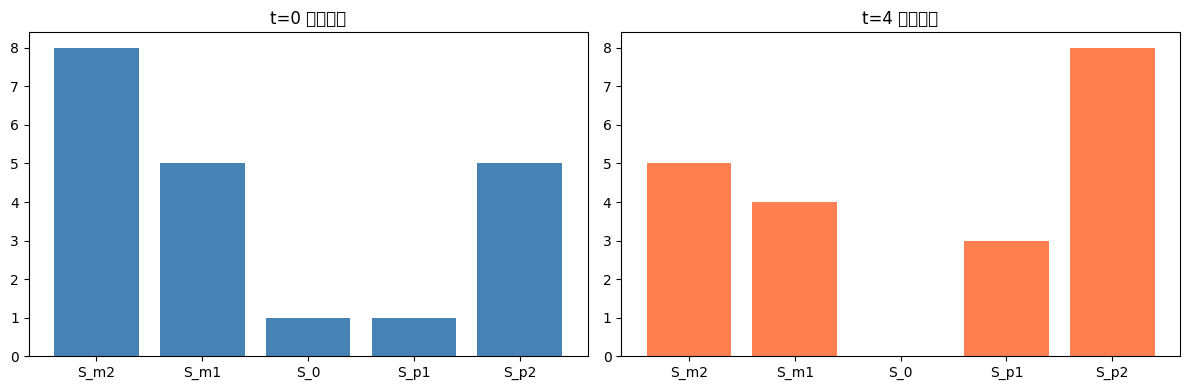

C:\Users\Bai Yuexi\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21344 (\N{CJK UNIFIED IDEOGRAPH-5360}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Bai Yuexi\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Bai Yuexi\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Bai Yuexi\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31435 (\N{CJK UNIFIED IDEOGRAPH-7ACB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Bai Yuexi\AppData\Roaming\Python\Python314\site-packages\IPytho

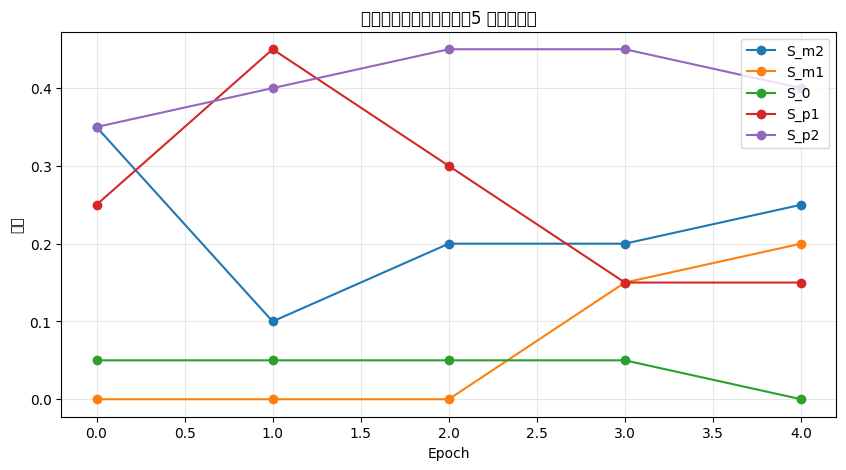


=== 三阵营占比演化 ===
camp_new   Dem   Mid   Rep
t                         
0         0.60  0.05  0.35
1         0.85  0.05  0.10
2         0.75  0.05  0.20
3         0.60  0.05  0.35
4         0.55  0.00  0.45


C:\Users\Bai Yuexi\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38453 (\N{CJK UNIFIED IDEOGRAPH-9635}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Bai Yuexi\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 33829 (\N{CJK UNIFIED IDEOGRAPH-8425}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Bai Yuexi\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21344 (\N{CJK UNIFIED IDEOGRAPH-5360}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Bai Yuexi\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Bai Yuexi\AppData\Roaming\Python\Python314\site-packages\IPytho

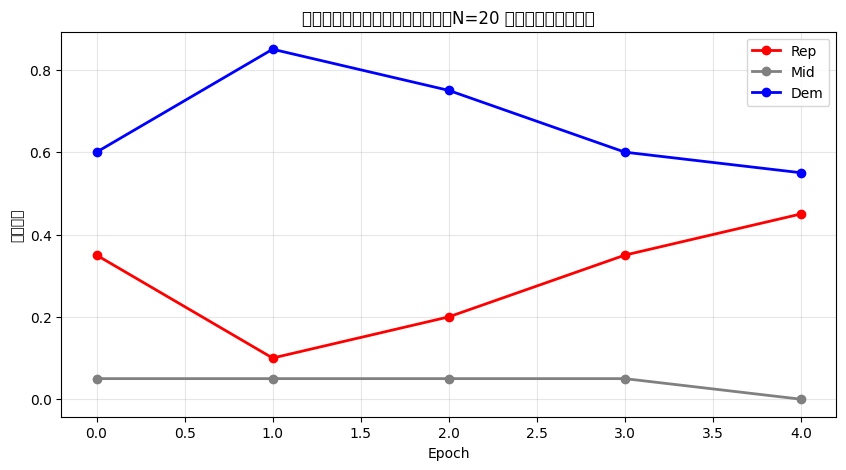


=== 指标 1: 中间立场 S_0 占比 ρ_mid(t) ===
t
0    0.05
1    0.05
2    0.05
3    0.05
4    0.00
Name: is_mid, dtype: float64
初始 ρ_mid = 5.00%，终态 ρ_mid = 0.00%
对比 Piao 报告：40% → 0.4%-22.5%（N=20 时该指标分辨力有限，因 S_0 通常只有 0-2 个 agent）

=== 指标 2: 总方差演化（锐化指标）===
t
0    3.144737
1    1.418421
2    2.378947
3    2.789474
4    3.039474
Name: new_val, dtype: float64
初始 = 3.14, 终态 = 3.04, 变化 -3.3%
负号 = 锐化（支持 H1），正号 = 散开

=== 指标 3: 平均立场演化（-2=强共和, +2=强民主）===
t
0    0.25
1    1.05
2    0.80
3    0.50
4    0.25
Name: new_val, dtype: float64
从 +0.25 → +0.25
如果终态显著偏向一侧（特别是 +1 以上偏民主），说明存在 RLHF progressive bias 主导


In [9]:
# Cell 8: 结果加载与可视化（升级版）
df = pd.read_json(out_path, lines=True)
print(f"读入 {len(df)} 条记录")

# 数值化立场（方便算方差和平均）
label2val = {"S_m2": -2, "S_m1": -1, "S_0": 0, "S_p1": 1, "S_p2": 2}
df["new_val"] = df["new_label"].map(label2val)
df["old_val"] = df["old_label"].map(label2val)

# ============= 图 1：t=0 vs t=终态 5 档分布对照 =============
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
t0_dist = df[df["t"] == 0]["old_val"].value_counts().sort_index()
tT_dist = df[df["t"] == df["t"].max()]["new_val"].value_counts().sort_index()
axes[0].bar(t0_dist.index, t0_dist.values, color="steelblue")
axes[0].set_title("t=0 立场分布")
axes[0].set_xticks([-2, -1, 0, 1, 2])
axes[0].set_xticklabels(["S_m2", "S_m1", "S_0", "S_p1", "S_p2"])
axes[1].bar(tT_dist.index, tT_dist.values, color="coral")
axes[1].set_title(f"t={df['t'].max()} 立场分布")
axes[1].set_xticks([-2, -1, 0, 1, 2])
axes[1].set_xticklabels(["S_m2", "S_m1", "S_0", "S_p1", "S_p2"])
plt.tight_layout()
plt.show()

# ============= 图 2：5 档占比随时间演化（细颗粒，含噪声）=============
# 修了 pandas 2.x 的 FutureWarning：用 assign + groupby 列代替 lambda apply
labels_view = ["S_m2", "S_m1", "S_0", "S_p1", "S_p2"]
fig, ax = plt.subplots(figsize=(10, 5))
for lab in labels_view:
    series = df.assign(is_lab=(df["new_label"] == lab)).groupby("t")["is_lab"].mean()
    ax.plot(series.index, series.values, marker="o", label=lab)
ax.set_xlabel("Epoch")
ax.set_ylabel("占比")
ax.set_title("各立场占比随时间演化（5 档细颗粒）")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

# ============= 图 3：三阵营聚合演化（去噪后的真正趋势视图）=============
def to_camp(lab):
    return {"S_m2": "Rep", "S_m1": "Rep", "S_0": "Mid",
            "S_p1": "Dem", "S_p2": "Dem"}[lab]

df["camp_new"] = df["new_label"].map(to_camp)
camp_series = (df.groupby("t")["camp_new"]
                 .value_counts(normalize=True)
                 .unstack(fill_value=0))
print("\n=== 三阵营占比演化 ===")
print(camp_series)

fig, ax = plt.subplots(figsize=(10, 5))
for c, color in [("Rep", "red"), ("Mid", "gray"), ("Dem", "blue")]:
    if c in camp_series.columns:
        ax.plot(camp_series.index, camp_series[c],
                marker="o", label=c, color=color, linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("阵营占比")
ax.set_title("三阵营聚合演化（消除单档噪声，N=20 真正能看清的视图）")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

# ============= 三个关键指标 =============
# 指标 1：中间立场占比 ρ_mid（Piao 原论文核心指标）
rho_mid = df.assign(is_mid=(df["new_label"] == "S_0")).groupby("t")["is_mid"].mean()
print("\n=== 指标 1: 中间立场 S_0 占比 ρ_mid(t) ===")
print(rho_mid)
print(f"初始 ρ_mid = {rho_mid.iloc[0]:.2%}，终态 ρ_mid = {rho_mid.iloc[-1]:.2%}")
print(f"对比 Piao 报告：40% → 0.4%-22.5%（N=20 时该指标分辨力有限，因 S_0 通常只有 0-2 个 agent）")

# 指标 2：总方差（H1 锐化的最直接证据）
var_series = df.groupby("t")["new_val"].var()
print("\n=== 指标 2: 总方差演化（锐化指标）===")
print(var_series)
print(f"初始 = {var_series.iloc[0]:.2f}, 终态 = {var_series.iloc[-1]:.2f}, 变化 {(var_series.iloc[-1]/var_series.iloc[0] - 1) * 100:+.1f}%")
print(f"负号 = 锐化（支持 H1），正号 = 散开")

# 指标 3：平均立场（H1 progressive bias 的方向指标）
mean_val = df.groupby("t")["new_val"].mean()
print("\n=== 指标 3: 平均立场演化（-2=强共和, +2=强民主）===")
print(mean_val)
print(f"从 {mean_val.iloc[0]:+.2f} → {mean_val.iloc[-1]:+.2f}")
print(f"如果终态显著偏向一侧（特别是 +1 以上偏民主），说明存在 RLHF progressive bias 主导")